In [19]:
import xarray as xr
import matplotlib.pyplot as plt
import glob
import numpy as np
import pandas as pd

In [2]:
fp = "/glade/campaign/uwyo/wyom0191/MAC-LWP/LWP_obs/"


In [26]:
ds_list = []
years = np.arange(2000, 2017)

for year in years:
    # error unless decode_times=False
    ds = xr.open_dataset(fp + f"maclwp_cloudlwpave_{year}_v1.nc4", decode_times=False)
    
    # fix time and add to list
    times = pd.date_range(start=f"{year}-01-01", end=f"{year}-12-31", freq="1ME")
    ds = ds.assign_coords({"time": times})
    ds.time.attrs = {"info": "assigned from indices using pd.date_range(start=f\"{year}-01-01\", end=f\"{year}-12-31\", freq=\"1ME\")"}
    ds_list.append(ds)

ds_all = xr.concat(ds_list, dim="time")


In [35]:
ds_am = ds.mean(dim="time")
ds_am = ds_am.where(ds_am >= 0)


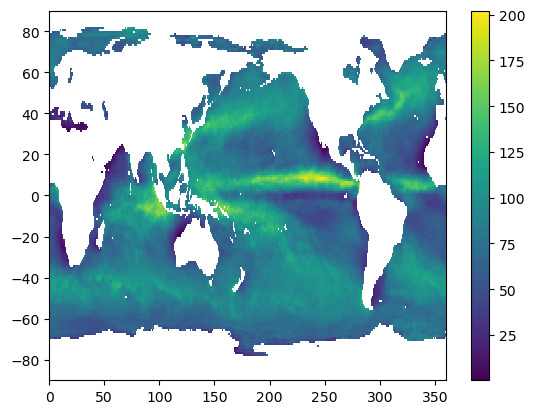

In [36]:
plt.pcolormesh(ds_am.lon, ds_am.lat, ds_am.cloudlwp)
plt.colorbar()

In [37]:
ds_am.to_netcdf("/glade/work/jnug/multi_PPE_data/MAC-LWP/MAC-LWP_annual_mean_LWP_2000-2016.nc")
